# 03 · Comparing propulsion architectures *fairly*

Five powertrains, **one mission** (same payload, same design range, same airframe assumptions): conventional kerosene, a SAF drop-in, a hybrid-electric, a hydrogen fuel-cell, and a fuel-cell + battery hybrid. The hard part of this comparison is not running the code — it is deciding what 'fair' means and which metric you rank on.

## What we hold fixed, and what we vary

All five use the same baseline mission and aerodynamics from `examples/common.py` (750 nm, ~4.5 t payload, ATR-like airframe). What changes is the **energy carrier and the conversion chain**. We read PhlyGreen's sized masses directly.

For climate we need to compare carriers as different as Jet-A, SAF, hydrogen and grid electricity. PhlyGreen's physics climate model (`ClimateImpact`, used in notebook 06) only prices **kerosene-burning gas turbines** — it cannot account hydrogen, fuel-cell or battery energy. So here we use transparent **well-to-wake intensity factors** instead: g CO₂e / MJ and a primary-energy ratio per carrier. These are *lifecycle factors you can edit*, not a proxy curve — and being explicit about them is the whole point of a 'fair' comparison.

In [1]:
import warnings
warnings.filterwarnings("ignore")     # keep the solver's internal chatter out of the output
import numpy as np
import matplotlib.pyplot as plt

from _learning_utils import add_examples_to_path
add_examples_to_path()                # puts trunk/examples on sys.path (no absolute paths)

import PhlyGreen as pg
from PhlyGreen import postprocess as pp

from common import (traditional_config, hybrid_config,
                    hydrogen_config, fuelcell_battery_config)
from _learning_utils import safe_design

# --- ILLUSTRATIVE well-to-wake (WtW) intensity factors -----------------------------------
# These are *lifecycle factors*, not a physics model: PhlyGreen's ClimateImpact module only
# prices kerosene-burning gas turbines, so to compare carriers as different as Jet-A, SAF,
# hydrogen and grid electricity on one footing we use transparent intensity factors. Change
# them and the ranking changes — that is the lesson.

# (a) CO2 intensity [g CO2e / MJ of delivered energy].
WTW_CO2 = {
    'jetA':    89.0,   # fossil Jet-A, combustion + upstream
    'saf':     20.0,   # sustainable aviation fuel (pathway-dependent!)
    'h2_green': 5.0,   # hydrogen from renewable electrolysis
    'grid':    56.0,   # battery electricity, ~200 gCO2/kWh EU-average grid (Ember/EEA 2023-24)
}

# (b) Well-to-tank ENERGY ratio [primary energy in / delivered energy out]. Producing green
#     fuels is lossy: e-SAF and liquid H2 need *far more* primary energy than their onboard
#     content. (Illustrative; real values are pathway-specific.)
WTT_ENERGY = {
    'jetA':    1.18,   # crude extraction + refining + transport (~85% efficient)
    'saf':     2.7,    # e-/bio-kerosene synthesis (electrolysis + Fischer-Tropsch, lossy)
    'h2_green': 2.0,   # electrolysis (~70%) + liquefaction (~75%) + distribution
    'grid':    1.15,   # charging + grid transmission losses
}
print("CO2  factors [gCO2e/MJ]:", WTW_CO2)
print("WtT energy ratios [-]  :", WTT_ENERGY)


CO2  factors [gCO2e/MJ]: {'jetA': 89.0, 'saf': 20.0, 'h2_green': 5.0, 'grid': 56.0}
WtT energy ratios [-]  : {'jetA': 1.18, 'saf': 2.7, 'h2_green': 2.0, 'grid': 1.15}


## Size every architecture

A hybrid is only as good as **where** it spends its battery. Two fundamentally different reasons to add a battery, and we use the *right* one for each architecture:

- **Energy hybridization (the hybrid-electric).** The battery supplies a large share of the *cruise* power, displacing kerosene with grid electricity. Lever: **CO₂**; cost: a big battery sized for cruise *energy*. Here: 50% of cruise power.
- **Power hybridization (the fuel-cell + battery).** The battery only covers part of the brief, high-power **take-off + climb** peak, so the fuel cell is sized for the lower *cruise* power — a smaller, lighter stack. Cruise runs on hydrogen alone.

We size each aircraft, then split its onboard energy into a *fuel/H₂* chemical part and a *battery* electrical part, and scale each up to **well-to-wake** energy through its production-chain losses.

In [2]:
def chemical_MJ(mass_kg, lhv_J):
    return (mass_kg or 0.0) * lhv_J / 1e6

def battery_MJ(mass_kg, specific_energy_Wh_kg):
    # battery *capacity* carried, used as the electrical-energy proxy [MJ]
    return (mass_kg or 0.0) * (specific_energy_Wh_kg or 0.0) * 3600.0 / 1e6

# --- two *deliberate* hybridization strategies (the heart of a fair comparison) ----------
# A hybrid is only as good as *where* it uses its battery; we pick a meaningful strategy for
# each, not a token one (see notebook text and example 23).

def hybrid_electric_config():
    # ENERGY hybridization: battery supplies 50% of cruise power, trading kerosene for grid
    # electricity. Pay-off is CO2; price is a big battery sized for cruise *energy*.
    cfg = hybrid_config('I')
    for s in cfg.mission_stages.segments:
        if s.segment_type == 'ConstantMachCruise':
            s.phi_start = s.phi_end = 0.5
    return cfg

def fc_battery_config():
    # POWER hybridization: battery covers part of the take-off + climb peak so the fuel cell
    # is sized for the lower CRUISE power (smaller, lighter stack). Cruise on hydrogen alone.
    cfg = fuelcell_battery_config(0.0)
    for s in cfg.mission_stages.segments:
        if s.name == 'Takeoff':
            s.phi = 0.2
        elif s.segment_type == 'ConstantRateClimb':
            s.phi_start = s.phi_end = 0.2
        elif s.segment_type == 'ConstantMachCruise':
            s.phi_start = s.phi_end = 0.0
    return cfg

def design_arch(spec):
    cfg = spec['make']()
    res, ok, note = safe_design(cfg)
    row = {'name': spec['name'], 'feasible': ok, 'limit': spec['limit']}
    if not ok:
        for k in ('WTO', 'fuel', 'batt', 'tank', 'onboard', 'wtw_energy', 'co2'):
            row[k] = np.nan
        return row, None
    a = pg.build_aircraft(); a.configure(cfg)              # rebuild to read masses + breakdown
    w = a.weight
    fuel = getattr(w, 'WH2_Fuel', None) or res.Wf          # H2 mass if present, else fuel
    batt = res.WBat or 0.0
    tank = getattr(w, 'WTank', None) or 0.0
    se = getattr(cfg, 'cell', None).specific_energy if getattr(cfg, 'cell', None) else \
         getattr(cfg.energy, 'battery_specific_energy', 0.0)
    e_fuel = chemical_MJ(fuel, cfg.energy.Ef)              # onboard chemical energy
    e_batt = battery_MJ(batt, se)                          # onboard electrical energy
    onboard = e_fuel + e_batt
    # well-to-wake: scale each onboard energy stream up by its production-chain losses
    wtw_energy = e_fuel * spec['e_factor'] + e_batt * WTT_ENERGY['grid']
    co2 = (e_fuel * spec['co2_factor'] + e_batt * WTW_CO2['grid']) / 1000.0   # kg CO2e
    row.update(WTO=res.WTO, fuel=fuel, batt=batt, tank=tank,
               onboard=onboard, wtw_energy=wtw_energy, co2=co2)
    return row, a

specs = [
    dict(name='Kerosene',   make=traditional_config,    limit='energy density / CO2',
         co2_factor=WTW_CO2['jetA'],     e_factor=WTT_ENERGY['jetA']),
    dict(name='SAF',        make=traditional_config,     limit='fuel supply / cost / energy',
         co2_factor=WTW_CO2['saf'],      e_factor=WTT_ENERGY['saf']),
    dict(name='Hybrid',     make=hybrid_electric_config, limit='battery mass (energy hybrid)',
         co2_factor=WTW_CO2['jetA'],     e_factor=WTT_ENERGY['jetA']),
    dict(name='H2 fuelcell',make=hydrogen_config,        limit='tank + fuel-cell mass / volume',
         co2_factor=WTW_CO2['h2_green'], e_factor=WTT_ENERGY['h2_green']),
    dict(name='FC+battery', make=fc_battery_config,      limit='peak-power battery -> smaller FC',
         co2_factor=WTW_CO2['h2_green'], e_factor=WTT_ENERGY['h2_green']),
]
rows, acft = [], {}
for s in specs:
    r, a = design_arch(s)
    rows.append(r); acft[s['name']] = a
print('sized', len(rows), 'architectures')


sized 5 architectures


> **SAF is modelled as a drop-in fuel swap** on the *same* airframe as kerosene — same WTO and fuel mass — differing only in its well-to-wake CO₂ *and energy* factors. That is itself a lesson: SAF changes the *lifecycle* numbers, not the aircraft. Its real limits are feedstock supply, cost, and the large primary energy its synthesis needs.

## The comparison table

MTOW, fuel/H₂ mass, battery mass, **H₂ tank mass**, **onboard** energy, **well-to-wake** energy, WtW CO₂, feasibility and the main limiting factor — side by side.

In [3]:
hdr = ['architecture','WTO','fuel/H2','battery','H2 tank','onboard E','WtW E','WtW CO2','feasible','main limit']
units = ['', '[kg]','[kg]','[kg]','[kg]','[MJ]','[MJ]','[kg]','','']
def fz(v):
    return '   n/a' if (v is None or (isinstance(v, float) and np.isnan(v))) else f'{v:,.0f}'
print(f"{hdr[0]:13s}{hdr[1]:>8s}{hdr[2]:>9s}{hdr[3]:>9s}{hdr[4]:>9s}{hdr[5]:>11s}{hdr[6]:>9s}{hdr[7]:>9s}  {hdr[8]:<8s} {hdr[9]}")
print(f"{units[0]:13s}{units[1]:>8s}{units[2]:>9s}{units[3]:>9s}{units[4]:>9s}{units[5]:>11s}{units[6]:>9s}{units[7]:>9s}")
for r in rows:
    print(f"{r['name']:13s}{fz(r['WTO']):>8s}{fz(r['fuel']):>9s}{fz(r['batt']):>9s}{fz(r['tank']):>9s}"
          f"{fz(r['onboard']):>11s}{fz(r['wtw_energy']):>9s}{fz(r['co2']):>9s}  {str(r['feasible']):<8s} {r['limit']}")


architecture      WTO  fuel/H2  battery  H2 tank  onboard E    WtW E  WtW CO2  feasible main limit
                 [kg]     [kg]     [kg]     [kg]       [MJ]     [MJ]     [kg]
Kerosene       18,327    1,908        0        0     82,979   97,915    7,385  True     energy density / CO2
SAF            18,327    1,908        0        0     82,979  224,044    1,660  True     fuel supply / cost / energy
Hybrid         24,413    1,333    2,970        0     74,042   86,888    6,060  True     battery mass (energy hybrid)
H2 fuelcell    27,745      549        0    1,019     65,874  131,748      329  True     tank + fuel-cell mass / volume
FC+battery     27,412      533    1,035      990     64,893  128,993      372  True     peak-power battery -> smaller FC


## Mass breakdown by architecture

Where does the take-off weight go? We stack **every** PhlyGreen mass group — including the **H₂ tank** and the fuel-cell **cooling** system, shown as their own bars — so the stack sums exactly to WTO (the black ticks). The hydrogen columns carry a large tank + powertrain burden the kerosene column does not.

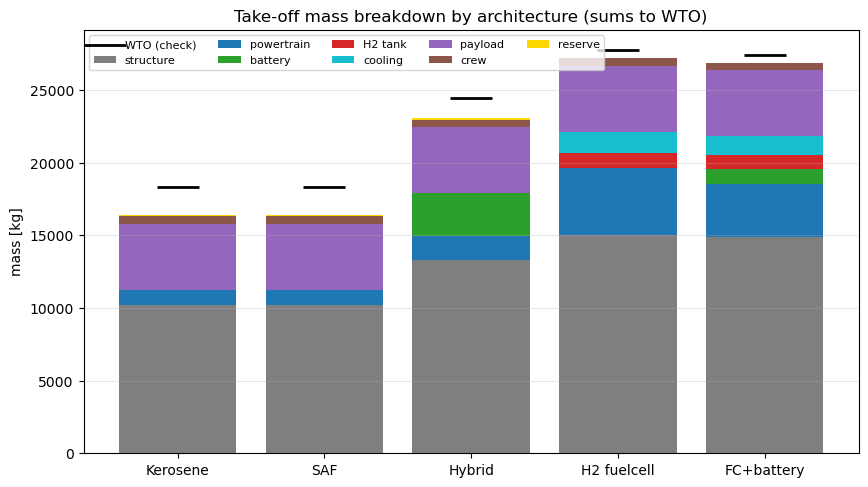

In [4]:
# Use *every* group PhlyGreen reports (incl. the separate 'H2 tank' and 'cooling'), so the
# stacked bars sum exactly to WTO. The black ticks mark each design's take-off weight: the
# bars now reach them (earlier the tank/cooling were dropped, so WTO was not recovered).
group_order = ['structure', 'powertrain', 'battery', 'fuel', 'H2 tank', 'cooling',
               'payload', 'crew', 'reserve']
colors = {'structure':'tab:gray', 'powertrain':'tab:blue', 'battery':'tab:green',
          'fuel / H2':'tab:orange', 'H2 tank':'tab:red', 'cooling':'tab:cyan',
          'payload':'tab:purple', 'crew':'tab:brown', 'reserve':'gold'}

names = [r['name'] for r in rows if r['feasible']]
breakdowns = {nm: pp.mass_breakdown(acft[nm]) for nm in names}
wto_by_name = {r['name']: r['WTO'] for r in rows if r['feasible']}
present = [g for g in group_order if any(g in breakdowns[nm] for nm in names)]

fig, ax = plt.subplots(figsize=(10, 5.5))
bottoms = np.zeros(len(names))
for g in present:
    vals = np.array([breakdowns[nm].get(g, 0.0) for nm in names])
    ax.bar(names, vals, bottom=bottoms, label=g, color=colors[g])
    bottoms += vals
# WTO check markers
ax.scatter(range(len(names)), [wto_by_name[nm] for nm in names], marker='_', s=900,
           color='black', linewidth=2, zorder=5, label='WTO (check)')
ax.set_ylabel('mass [kg]'); ax.set_title('Take-off mass breakdown by architecture (sums to WTO)')
ax.legend(ncol=5, fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.show()


## Energy and CO₂

Two views. Left: **onboard** energy (what the mission needs through each chain) next to **well-to-wake** energy (what it costs upstream to *make* that energy). Right: the well-to-wake CO₂. Watch the rankings disagree.

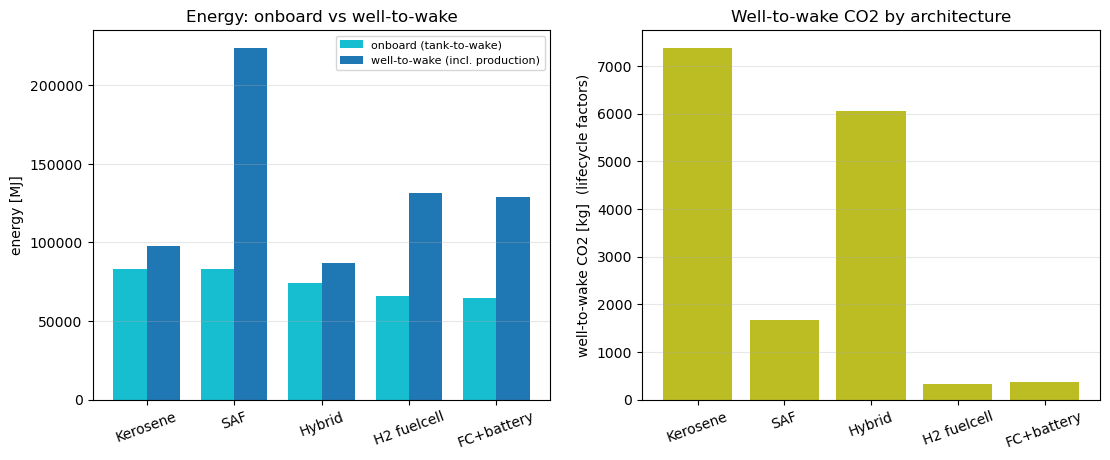

In [5]:
ok = [r for r in rows if r['feasible']]
labels = [r['name'] for r in ok]
x = np.arange(len(labels)); width = 0.38
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

ax1.bar(x - width/2, [r['onboard'] for r in ok], width, label='onboard (tank-to-wake)', color='tab:cyan')
ax1.bar(x + width/2, [r['wtw_energy'] for r in ok], width, label='well-to-wake (incl. production)', color='tab:blue')
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=20)
ax1.set_ylabel('energy [MJ]'); ax1.set_title('Energy: onboard vs well-to-wake')
ax1.grid(axis='y', alpha=0.3); ax1.legend(fontsize=8)

ax2.bar(labels, [r['co2'] for r in ok], color='tab:olive')
ax2.set_ylabel('well-to-wake CO2 [kg]  (lifecycle factors)')
ax2.set_title('Well-to-wake CO2 by architecture')
ax2.tick_params(axis='x', rotation=20); ax2.grid(axis='y', alpha=0.3)
plt.show()


## CO₂-equivalent — adding the non-CO₂ of the gas turbine

Well-to-wake CO₂ is not the whole climate story for the **combustion** architectures: their gas
turbines also emit NOx (and CO/UHC). Using PhlyGreen's **emission-index surrogate** (the PW127
model) + the `ClimateImpact` radiative-forcing machinery, we express each architecture's total
warming as a **CO₂-equivalent** = CO₂ + the non-CO₂ contribution. The fuel-cell aircraft burn no
hydrocarbon, so they carry **no combustion NOx** (their only non-CO₂ would be contrails, deferred).
For this *regional turboprop* the GT non-CO₂ uplift is small (it cruises low and lean) — but it is
real, it is computed from the emission model, and it only burdens the combustion architectures.

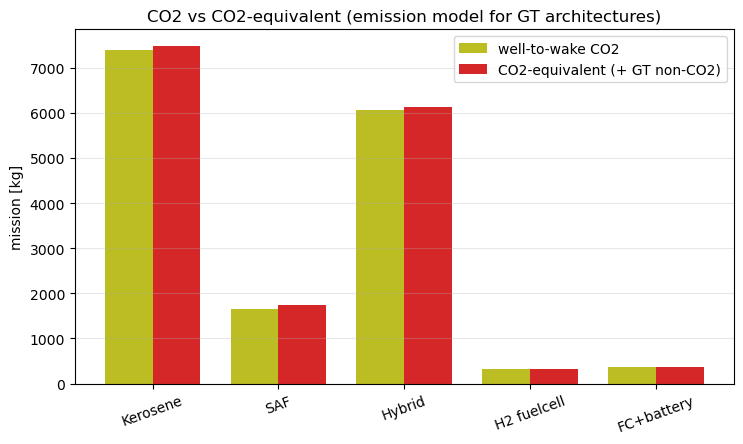

  Kerosene     CO2    7385 -> CO2e    7475 kg  (+1.2% from GT non-CO2)
  SAF          CO2    1660 -> CO2e    1750 kg  (+5.4% from GT non-CO2)
  Hybrid       CO2    6060 -> CO2e    6127 kg  (+1.1% from GT non-CO2)
  H2 fuelcell  CO2     329 -> CO2e     329 kg  (+0.0% from GT non-CO2)
  FC+battery   CO2     372 -> CO2e     372 kg  (+0.0% from GT non-CO2)


In [6]:
from _learning_utils import attach_climate_model, climate_co2_equivalent

def _gt_nonco2_co2e(make):
    """Absolute non-CO2 CO2-equivalent [kg] of a GT design, from the emission surrogate + ATR."""
    cfg = make(); attach_climate_model(cfg)            # default emissions model = PW127 surrogate
    a = pg.build_aircraft(); a.configure(cfg); a.MissionType = "Continue"
    co2e, uplift = climate_co2_equivalent(a)
    return co2e * (1.0 - 1.0 / uplift)                 # co2e - co2 = the non-CO2 part

# SAF shares the kerosene airframe -> same combustion NOx; fuel cells have no combustion NOx.
nonco2_kero = _gt_nonco2_co2e(traditional_config)
nonco2_hyb  = _gt_nonco2_co2e(hybrid_electric_config)
nonco2 = {"Kerosene": nonco2_kero, "SAF": nonco2_kero, "Hybrid": nonco2_hyb,
          "H2 fuelcell": 0.0, "FC+battery": 0.0}

ok = [r for r in rows if r["feasible"]]
labels = [r["name"] for r in ok]
co2  = np.array([r["co2"] for r in ok])
co2e = co2 + np.array([nonco2.get(n, 0.0) for n in labels])

x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.bar(x - w/2, co2,  w, label="well-to-wake CO2", color="tab:olive")
ax.bar(x + w/2, co2e, w, label="CO2-equivalent (+ GT non-CO2)", color="tab:red")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20)
ax.set_ylabel("mission [kg]"); ax.set_title("CO2 vs CO2-equivalent (emission model for GT architectures)")
ax.grid(axis="y", alpha=0.3); ax.legend()
plt.show()
for n, c, ce in zip(labels, co2, co2e):
    print(f"  {n:12} CO2 {c:7.0f} -> CO2e {ce:7.0f} kg  ({100*(ce/c-1):+.1f}% from GT non-CO2)")

Read these critically:

- The **well-to-wake energy** tells a different story from mass or onboard energy: SAF and hydrogen need **far more primary energy** to produce than they carry, because electrolysis / synthesis / liquefaction are lossy. A 'zero-CO₂' fuel can still demand 2–3× the primary energy — which has to come from somewhere.
- The **hybrid-electric** cuts WtW CO₂ versus kerosene *only because the grid is relatively clean* (56 < 89 gCO₂e/MJ) and pays for it with a large jump in take-off weight: **CO₂ down, mass up**. On a coal-heavy grid the saving reverses.
- The **fuel-cell + battery** uses *power* hybridization: a small take-off/climb battery lets the fuel cell be sized for cruise, so its take-off weight is close to the pure-hydrogen aircraft — a genuinely useful hybrid, not dead weight.
- The H₂ and electrified aircraft look clean **only if the hydrogen is green and the grid is clean** — assumptions baked into `WTW_CO2`/`WTT_ENERGY`. Change them and the ranking moves.

## Key takeaways

1. A 'fair' comparison means **same mission and airframe assumptions** — and being explicit about every efficiency and lifecycle factor.
2. The **ranking depends on the metric**: lightest, least onboard energy, least *primary* energy, and least CO₂ are often *different* aircraft.
3. The most influential inputs are frequently **off-aircraft** assumptions (where the hydrogen / electricity / SAF comes from), not the aircraft model itself.

## Questions for students

1. What does **'fair comparison'** mean here? List three things you had to hold fixed and one you could not.
2. Why can an architecture have **low onboard energy but high well-to-wake energy**? Which matters for the climate, and which for the airline's tank?
3. Which single assumption most influences the CO₂ ranking — change the factors to find out — and which influences the *energy* ranking?

## Suggested modifications

- **Decarbonise / dirty the grid.** Set `WTW_CO2['grid'] = 14` (French/Nordic) or `222` (coal-heavy) and re-rank — the hybrid can flip from best to worst.
- **Grey hydrogen.** Set `WTW_CO2['h2_green'] = 90` and `WTT_ENERGY['h2_green'] = 1.4` (reformed natural gas) and watch H₂ lose its climate edge.
- **Cheaper green fuels.** Lower `WTT_ENERGY['saf']` / `['h2_green']` toward 1.5 (future electrolysers) and see the primary-energy gap shrink.
- **Change the hybrid strategy.** Raise the cruise `phi` in `hybrid_electric_config`, or sweep the take-off/climb `phi` in `fc_battery_config` (see example 23).
- Swap `hydrogen_config()` for `hydrogen_config(tank=True)` (needs CoolProp) for a real LH₂ tank mass.

---
*These tutorials are educational. The cross-carrier CO₂ and energy numbers here come from **illustrative well-to-wake intensity factors** (the `WTW_CO2` / `WTT_ENERGY` dicts), not a physics model — PhlyGreen's `ClimateImpact` only prices kerosene gas turbines (see notebook 06 for the real ATR on a kerosene aircraft). Change the factors and re-rank before trusting any number.*